# NB03: Pinecone GraphRAG (Section B)

## What
This notebook implements GraphRAG retrieval on Pinecone and compares it side-by-side with the ChromaDB baseline.

## Why
Pinecone introduces managed vector infrastructure for production scaling, while preserving the same GraphRAG retrieval logic.

## When
Use this notebook when you need cloud-native vector serving, multi-environment deployment, and managed scaling.

## Tradeoffs
- Managed service reduces operational burden but adds direct usage costs.
- Network hops can increase tail latency versus local ChromaDB.
- Cloud deployment improves scale posture but increases credential and environment management complexity.

## Alternatives
- **Why Pinecone**: managed service, mature APIs, straightforward scaling path.
- **Why not Chroma only**: local-first setup is excellent for development but limited for multi-instance production throughput.
- **Why not self-hosted Weaviate/Qdrant**: strong options, but require operating and monitoring additional services.

## Production Considerations
- Keep collection/index schema equivalent across stores for fair quality comparisons.
- Measure both retrieval quality and latency; optimize only after tradeoff visibility.
- Use index lifecycle policy (create/use/delete) to control spend in experiments.

In [1]:
# Input: persisted artifacts from NB01 and NB02.
# Output: runtime initialized for Pinecone and comparison benchmarking.
# Logic: load chunks/embeddings/graph artifacts and retrieval helpers.
# Complexity: O(number_of_chunks + V + E).
from __future__ import annotations

import json
import pickle
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.chroma_retriever import get_collection, reciprocal_rank_fusion
from src.chunking import build_chunk_lookup, load_chunks
from src.config import settings
from src.data_pipeline import build_extractive_eval_queries, load_persisted_records
from src.embeddings import embed_query, load_embedding_bundle
from src.evaluator import RetrievalExample, compute_retrieval_metrics
from src.graph_builder import concept_id_from_query, local_graph_expansion
from src.pinecone_retriever import (
    delete_index,
    index_chunks_to_pinecone,
    pinecone_cost_proxy,
    query_pinecone,
)
from src.utils import save_plot, timed_block

plt.rcParams["figure.figsize"] = (10, 6)

print(f"Pinecone region: {settings.pinecone_cloud}/{settings.pinecone_region}")
print(f"Pinecone index prefix: {settings.pinecone_index_prefix}")

Pinecone region: aws/us-east-1
Pinecone index prefix: medmentions-graphrag


## Step 1: Load Reusable Artifacts

The notebook reuses the exact chunk and graph artifacts from Section A to keep comparisons fair.

In [2]:
# Input: persisted records/chunks/embeddings/graph files.
# Output: in-memory artifacts for retrieval and evaluation.
# Logic: load canonical persisted artifacts from prior notebooks.
# Complexity: O(number_of_files).
records = load_persisted_records()
chunks = load_chunks()
chunk_lookup = build_chunk_lookup(chunks)
embedding_bundle = load_embedding_bundle(settings.processed_dir)

with (settings.graph_dir / "entity_graph.pkl").open("rb") as f:
    graph = pickle.load(f)

chroma_collection = get_collection("medmentions_chroma_section_a")
chroma_payload = chroma_collection.get(include=["metadatas", "documents"])

print(f"Records: {len(records):,}")
print(f"Chunks: {len(chunks):,}")
print("Embeddings:", embedding_bundle.matrix.shape)

Records: 4,392
Chunks: 5,098
Embeddings: (5098, 2560)


## Step 2: Index Vectors in Pinecone

We create an experiment-scoped Pinecone index and upload chunk vectors with metadata.

In [3]:
# Input: chunks, embeddings, and Pinecone credentials.
# Output: populated Pinecone index.
# Logic: create index if needed and upsert vectors in batches.
# Complexity: O(number_of_chunks).
pinecone_index_name = f"{settings.pinecone_index_prefix}-section-b"

with timed_block("Index Pinecone vectors"):
    index_chunks_to_pinecone(
        chunks=chunks,
        embeddings=embedding_bundle.matrix,
        index_name=pinecone_index_name,
        namespace="section_b",
        batch_size=100,
    )

print("Pinecone index ready:", pinecone_index_name)

2026-06-22 09:53:12 | INFO | Pinecone index medmentions-graphrag-section-b already exists
2026-06-22 09:53:12 | INFO | create_index completed in 2.36s


2026-06-22 09:55:02 | INFO | Indexed 5098 vectors to Pinecone index medmentions-graphrag-section-b
2026-06-22 09:55:02 | INFO | index_chunks_to_pinecone completed in 112.47s
2026-06-22 09:55:02 | INFO | Index Pinecone vectors completed in 112.47s
Pinecone index ready: medmentions-graphrag-section-b


## Step 3: Define Matched GraphRAG Retrieval

Pinecone retrieval is matched to Chroma GraphRAG behavior:
1. Semantic vector retrieval.
2. Graph-aware entity reranking channel.
3. Reciprocal rank fusion.

In [4]:
# Input: query string.
# Output: fused GraphRAG retrieval list.
# Logic: combine vector channel + graph-expanded entity channel with RRF.
# Complexity: O(ANN query + top-k rerank).
def pinecone_graphrag_search(query: str, top_k: int = 8) -> list[dict]:
    vector_results = query_pinecone(
        query=query,
        index_name=pinecone_index_name,
        namespace="section_b",
        top_k=top_k * 3,
    )

    query_concepts = concept_id_from_query(query, chunks)
    local_ctx = local_graph_expansion(graph, query_concepts, hops=settings.local_graph_hops)
    expanded_concepts = set(local_ctx.get("nodes", [])[:120])

    entity_results: list[dict] = []
    for item in vector_results:
        concepts_str = item.get("metadata", {}).get("concept_ids", "")
        matches = sum(1 for concept in expanded_concepts if concept and concept in concepts_str)
        if matches <= 0:
            continue
        entity_results.append(
            {
                "id": item["id"],
                "text": item.get("text", ""),
                "metadata": item.get("metadata", {}),
                "score": float(matches),
                "source": "entity",
            }
        )

    entity_results.sort(key=lambda x: x["score"], reverse=True)
    return reciprocal_rank_fusion(
        {
            "vector": vector_results[: top_k * 2],
            "entity": entity_results[: top_k * 2],
        },
        top_k=top_k,
    )


# Chroma baseline helper for direct comparison.
def chroma_graphrag_search(query: str, top_k: int = 8) -> list[dict]:
    query_concepts = concept_id_from_query(query, chunks)
    local_ctx = local_graph_expansion(graph, query_concepts, hops=settings.local_graph_hops)

    # Use explicit query embeddings from the same Ollama model used at index time.
    # This avoids Chroma defaulting to a different embedding function/dimension.
    query_vector = embed_query(query).tolist()
    chroma_raw = chroma_collection.query(
        query_embeddings=[query_vector],
        n_results=top_k * 2,
        include=["metadatas", "documents", "distances"],
    )

    vector_results = []
    for i, chunk_id in enumerate(chroma_raw["ids"][0]):
        distance = float(chroma_raw["distances"][0][i])
        vector_results.append(
            {
                "id": chunk_id,
                "text": chroma_raw["documents"][0][i],
                "metadata": chroma_raw["metadatas"][0][i],
                "score": 1.0 - distance,
                "source": "vector",
            }
        )

    entity_results = []
    for i, chunk_id in enumerate(chroma_payload["ids"]):
        meta = chroma_payload["metadatas"][i]
        concepts_str = meta.get("concept_ids", "")
        matches = sum(1 for concept in local_ctx.get("nodes", [])[:120] if concept and concept in concepts_str)
        if matches <= 0:
            continue
        entity_results.append(
            {
                "id": chunk_id,
                "text": chroma_payload["documents"][i],
                "metadata": meta,
                "score": float(matches),
                "source": "entity",
            }
        )

    entity_results.sort(key=lambda x: x["score"], reverse=True)
    return reciprocal_rank_fusion(
        {
            "vector": vector_results[: top_k * 2],
            "entity": entity_results[: top_k * 2],
        },
        top_k=top_k,
    )

## Step 4: Build Real Evaluation Query Set

We evaluate retrieval with extractive queries from real MedMentions abstracts.

In [5]:
# Input: records and PMID->chunk mapping.
# Output: extractive evaluation query objects.
# Logic: deterministic query construction grounded in real source text.
# Complexity: O(records * entities).
eval_queries = build_extractive_eval_queries(
    records=records,
    chunk_lookup=chunk_lookup,
    sample_size=min(settings.eval_query_count, 50),
)
print("Evaluation queries:", len(eval_queries))

2026-06-22 09:55:03 | INFO | Built 30 extractive evaluation queries
Evaluation queries: 30


## Step 5: Compare ChromaDB vs Pinecone

Metrics compared:
- Latency: p50, p95, p99
- Retrieval quality: Precision@K, Recall@K, F1@K, MRR, NDCG
- Cost drivers: query/upsert volume and vector footprint
- Complexity and scalability scoring for decision transparency

In [6]:
# Input: evaluation queries and retrieval functions.
# Output: benchmark summaries for both backends.
# Logic: run per-query retrieval, collect metrics, aggregate latency percentiles.
# Complexity: O(num_queries * retrieval_cost).
def benchmark_backend(name: str, fn):
    retrieval_examples: list[RetrievalExample] = []
    latency_ms: list[float] = []

    for item in eval_queries:
        start = time.perf_counter()
        rows = fn(item.query, top_k=settings.top_k_retrieval)
        latency_ms.append((time.perf_counter() - start) * 1000)
        retrieval_examples.append(
            RetrievalExample(
                retrieved_ids=[row["id"] for row in rows],
                relevant_ids=item.supporting_chunk_ids,
            )
        )

    metrics = compute_retrieval_metrics(retrieval_examples, k_values=[1, 3, 5, 8])
    arr = np.asarray(latency_ms, dtype=float)
    return {
        "name": name,
        "latency_ms": latency_ms,
        "latency_p50_ms": float(np.percentile(arr, 50)),
        "latency_p95_ms": float(np.percentile(arr, 95)),
        "latency_p99_ms": float(np.percentile(arr, 99)),
        "metrics": metrics,
    }

with timed_block("Benchmark Chroma GraphRAG"):
    chroma_benchmark = benchmark_backend("ChromaDB", chroma_graphrag_search)

with timed_block("Benchmark Pinecone GraphRAG"):
    pinecone_benchmark = benchmark_backend("Pinecone", pinecone_graphrag_search)

pinecone_cost = pinecone_cost_proxy(
    index_name=pinecone_index_name,
    query_count=len(eval_queries),
    upsert_count=len(chunks),
    namespace="section_b",
)

comparison_df = pd.DataFrame(
    [
        {
            "backend": "ChromaDB",
            "latency_p50_ms": chroma_benchmark["latency_p50_ms"],
            "latency_p95_ms": chroma_benchmark["latency_p95_ms"],
            "latency_p99_ms": chroma_benchmark["latency_p99_ms"],
            **chroma_benchmark["metrics"],
            "cost_driver": f"queries={len(eval_queries)}, vectors={len(chunks)}",
            "complexity_score_1_to_5": 2,
            "scalability_score_1_to_5": 3,
        },
        {
            "backend": "Pinecone",
            "latency_p50_ms": pinecone_benchmark["latency_p50_ms"],
            "latency_p95_ms": pinecone_benchmark["latency_p95_ms"],
            "latency_p99_ms": pinecone_benchmark["latency_p99_ms"],
            **pinecone_benchmark["metrics"],
            "cost_driver": (
                f"queries={pinecone_cost['query_count']}, "
                f"upserts={pinecone_cost['upsert_count']}, vectors={pinecone_cost['total_vectors']}"
            ),
            "complexity_score_1_to_5": 3,
            "scalability_score_1_to_5": 5,
        },
    ]
)

comparison_df

2026-06-22 09:55:09 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 09:55:09 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 09:55:09 | INFO | embed_texts completed in 0.31s


2026-06-22 09:55:15 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 09:55:15 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 09:55:15 | INFO | embed_texts completed in 0.22s


2026-06-22 09:55:21 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 09:55:21 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 09:55:21 | INFO | embed_texts completed in 0.18s


2026-06-22 09:55:27 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 09:55:27 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 09:55:27 | INFO | embed_texts completed in 0.17s


2026-06-22 09:55:33 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 09:55:33 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 09:55:33 | INFO | embed_texts completed in 0.22s


...

2026-06-22 10:02:36 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:02:36 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:02:36 | INFO | embed_texts completed in 0.16s


2026-06-22 10:02:46 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:02:46 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:02:46 | INFO | embed_texts completed in 0.17s


2026-06-22 10:02:55 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:02:55 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:02:55 | INFO | embed_texts completed in 0.15s


2026-06-22 10:03:04 | INFO | compute_retrieval_metrics completed in 0.00s
2026-06-22 10:03:04 | INFO | Benchmark Pinecone GraphRAG completed in 300.22s


,backend,latency_p50_ms,latency_p95_ms,latency_p99_ms,precision@1,recall@1,f1@1,ndcg@1,precision@3,recall@3,...,f1@5,ndcg@5,precision@8,recall@8,f1@8,ndcg@8,mrr,cost_driver,complexity_score_1_to_5,scalability_score_1_to_5
0,ChromaDB,5973.135145,6672.913734,6773.325430,0.200000,0.183333,0.188889,0.200000,0.077778,0.20,...,0.085714,0.210219,0.041667,0.300000,0.072593,0.232441,0.216190,"queries=30, vectors=5098",2,3
1,Pinecone,9657.659211,11888.915451,14086.928737,0.066667,0.066667,0.066667,0.066667,0.088889,0.25,...,0.130159,0.216453,0.070833,0.516667,0.123704,0.272176,0.187897,"queries=30, upserts=5098, vectors=5098",3,5


## Step 6: Tables and Charts

We persist comparison tables/charts for README integration.

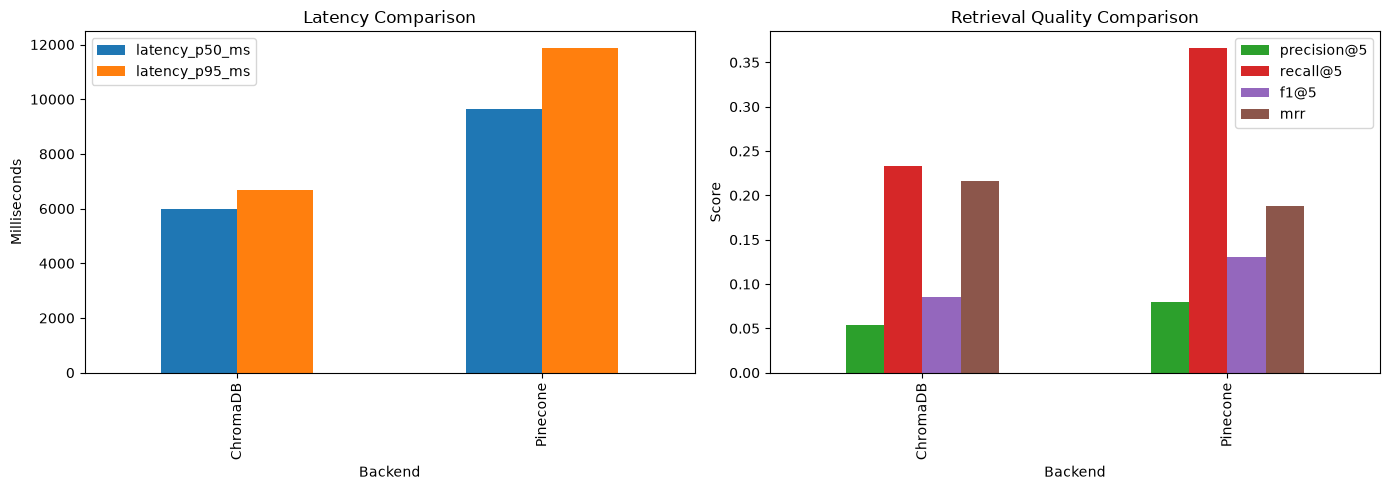

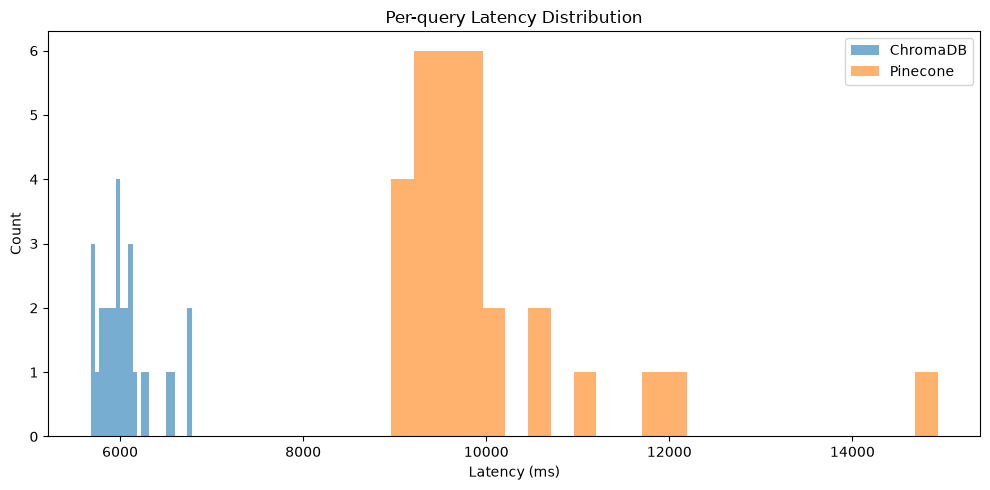

In [7]:
# Input: comparison dataframe and latency samples.
# Output: saved benchmark tables and charts.
# Logic: persist key decision metrics and visualize latency/quality deltas.
# Complexity: O(num_metrics).
comparison_df.to_csv(settings.tables_dir / "nb03_chroma_vs_pinecone.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison_df.set_index("backend")[["latency_p50_ms", "latency_p95_ms"]].plot(
    kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e"]
)
axes[0].set_title("Latency Comparison")
axes[0].set_ylabel("Milliseconds")
axes[0].set_xlabel("Backend")

comparison_df.set_index("backend")[["precision@5", "recall@5", "f1@5", "mrr"]].plot(
    kind="bar", ax=axes[1], color=["#2ca02c", "#d62728", "#9467bd", "#8c564b"]
)
axes[1].set_title("Retrieval Quality Comparison")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("Backend")

save_plot(settings.figures_dir / "nb03_chroma_pinecone_comparison.png")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(chroma_benchmark["latency_ms"], bins=24, alpha=0.6, label="ChromaDB", color="#1f77b4")
plt.hist(pinecone_benchmark["latency_ms"], bins=24, alpha=0.6, label="Pinecone", color="#ff7f0e")
plt.title("Per-query Latency Distribution")
plt.xlabel("Latency (ms)")
plt.ylabel("Count")
plt.legend()
save_plot(settings.figures_dir / "nb03_latency_distribution.png")
plt.show()

## Step 7: Save Benchmark Payload and Cleanup Option

- Existing historical outputs from prior runs are retained for tutorial comparisons.
- Newly introduced outputs are saved as part of notebook logic but should be validated during the explicit execution phase.

In [8]:
# Input: benchmark dictionaries and comparison table.
# Output: persisted benchmark JSON and optional index cleanup.
# Logic: save machine-readable benchmark payload and support optional spend cleanup.
# Complexity: O(num_queries).
benchmark_payload = {
    "chroma": {
        "metrics": chroma_benchmark["metrics"],
        "latency_summary": {
            "p50_ms": chroma_benchmark["latency_p50_ms"],
            "p95_ms": chroma_benchmark["latency_p95_ms"],
            "p99_ms": chroma_benchmark["latency_p99_ms"],
        },
    },
    "pinecone": {
        "metrics": pinecone_benchmark["metrics"],
        "latency_summary": {
            "p50_ms": pinecone_benchmark["latency_p50_ms"],
            "p95_ms": pinecone_benchmark["latency_p95_ms"],
            "p99_ms": pinecone_benchmark["latency_p99_ms"],
        },
        "cost_proxy": pinecone_cost,
    },
    "notes": {
        "historical_outputs_kept": True,
        "execution_phase_required_for_validation": True,
    },
}

(settings.metrics_dir / "nb03_retrieval_benchmark.json").write_text(
    json.dumps(benchmark_payload, indent=2, ensure_ascii=True),
    encoding="utf-8",
)

cleanup_index = False
if cleanup_index:
    delete_index(pinecone_index_name)

print("Saved NB03 Pinecone comparison artifacts.")

Saved NB03 Pinecone comparison artifacts.
